This is simple example showing generation of IFCs  using hiphive code using machine learning models. Adapted from https://gitlab.com/materials-modeling/hiphive-examples. Requires phonopy. hiphive and related libraries.


In [38]:
 # Setup plotting, seaborn is just used to make figures look a bit nicer not required
%matplotlib inline
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_context('talk')
except ModuleNotFoundError:
    print('Dont worry')

In [60]:
import numpy as np
from ase.io import read
from ase.db import connect
from hiphive import ClusterSpace, StructureContainer
from hiphive.utilities import get_displacements
from trainstation import Optimizer
from hiphive import ClusterSpace, StructureContainer, ForceConstantPotential
from phonopy import Phonopy
from phonopy.structure.atoms import PhonopyAtoms
from ase import Atoms

Lets describe the cutoff paramters here. convergence should be check wrt to these parameters.

In [40]:
cutoffs = [6.65, 4.0, 2.5]
cutoffs_str = str(cutoffs)[1:-1].replace(', ', '_')
sc_fname = 'sc_cutoffs-{}.sc'.format(cutoffs_str)

Setup cluster space and Structure Container. And Feed raw data training structures from DFT simulations which is stored as ase data base.

In [41]:
atoms_ideal = read('./POSCAR_ideal_size5')
cs = ClusterSpace(atoms_ideal, cutoffs)
sc = StructureContainer(cs)
db = connect('./silicon-bulk-dft-n5-rattled-0.03.db')

for row in db.select():

    # get displacements and forces
    atoms = row.toatoms()
    forces = atoms.get_forces()
    displacements = get_displacements(atoms, atoms_ideal)

    # sanity check
    max_disp = np.max(np.linalg.norm(displacements, axis=1))
    assert max_disp < 0.5

    # add atoms to StructureContainer
    atoms.positions = atoms_ideal.get_positions()
    atoms.new_array('forces', forces)
    atoms.new_array('displacements', displacements)
    sc.add_structure(atoms)

# write to file
sc.write(sc_fname)

Primitive cell:
    Formula: Si2
    Cell:
        [  0.00000   2.71548   2.71548]
        [  2.71548   0.00000   2.71548]
        [  2.71548   2.71548   0.00000]
    Basis:
        Si  [  0.01841   0.01841   0.01841]
        Si  [  0.26841   0.26841   0.26841]

Crystal symmetry:
    Spacegroup:          Fd-3m (227)
    Unique site:         1
    Symmetry operations: 48
    symprec:             1.00e-05

Cutoffs:
    Maximum cutoff: 6.65
    Found 2 center atoms with 60 images totaling 62 atoms

Clusters:
    Clusters: {2: 93, 3: 142, 4: 23}
    Total number of clusters: 258

Orbits:
    Orbits: {2: 6, 3: 6, 4: 3}
    Total number of orbits: 15

Eigentensors:
    Eigentensors: {2: 17, 3: 36, 4: 14}
    Total number of parameters: 67

Constraints:
    Acoustic: True
    Number of degrees of freedom: {2: 16, 3: 27, 4: 4}
    Total number of degrees of freedom: 47


Lets use the structure container from above to get IFCs

In [42]:
dim = np.diag([5, 5,5])
prim = read('PPOSCAR')
atoms_ideal = read('POSCAR_ideal_size5')

6.65_4.0_2.5
Running opt for least-squares_cutoffs-6.65_4.0_2.5
===================== Optimizer ======================
seed                           : 42
fit_method                     : least-squares
standardize                    : True
n_target_values                : 15000
n_parameters                   : 47
n_nonzero_parameters           : 47
parameters_norm                : 13.18099
target_values_std              : 0.3299507
rmse_train                     : 0.006785278
rmse_test                      : 0.006901678
R2_train                       : 0.9995772
R2_test                        : 0.9995619
AIC                            : -119738
BIC                            : -119390.5
train_size                     : 12000
test_size                      : 3000
test  error:   0.006902 (eV/Å)
train error:   0.006785 (eV/Å)


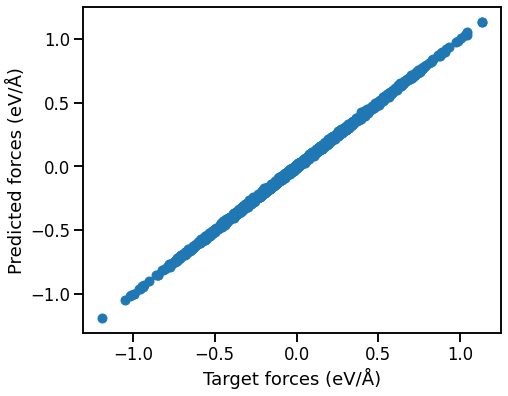

In [68]:
fit_methods = ['least-squares']# 'rfe', 'ardr']
cutoffs1 = [[6.65, 4.0, 2.5]]
for cutoffs in cutoffs1:
    cutoffs_str = str(cutoffs)[1:-1].replace(', ', '_')
    print(cutoffs_str)
    sc_fname = 'sc_cutoffs-{}.sc'.format(cutoffs_str)
    sc = StructureContainer.read(sc_fname)
    cs = sc.cluster_space
    for fit_method in fit_methods:
        tag = '{}_cutoffs-{}'.format(fit_method, cutoffs_str)
        print('Running opt for {}'.format(tag))    
        opt = Optimizer(sc.get_fit_data(),  fit_method=fit_method, train_size=0.8)
        opt.train()
        print(opt)      
        print('test  error: {:10.6f} (eV/Å)'.format(opt.rmse_test))
        print('train error: {:10.6f} (eV/Å)'.format(opt.rmse_train))
        sd = opt.scatter_data_test
        fig = plt.figure(figsize=(7.5, 6))
        plt.plot(sd.target, sd.predicted, 'o')
        plt.xlabel('Target forces (eV/Å)')
        plt.ylabel('Predicted forces (eV/Å)');
        fcp_fname = 'fcp_{}.fcp'.format(tag)
        fcp = ForceConstantPotential(cs, params)
        fcp.write(fcp_fname)

In [69]:
atoms_phonopy = PhonopyAtoms(symbols=prim.get_chemical_symbols(),
                             scaled_positions=prim.get_scaled_positions(),
                             cell=prim.cell)
phonopy = Phonopy(atoms_phonopy, supercell_matrix=dim,
                  primitive_matrix=None)


supercell = phonopy.get_supercell()
supercell = Atoms(cell=supercell.cell, numbers=supercell.numbers, pbc=True,
                  scaled_positions=supercell.get_scaled_positions())
fcs = fcp.get_force_constants(supercell)
 # get second order force constants
fc2 = fcs.get_fc_array(order=2)
print(fc2.shape)

# compute IFCs for phonopy
phonopy.set_force_constants(fc2)

(250, 250, 3, 3)


Now lets plot the dispersion.

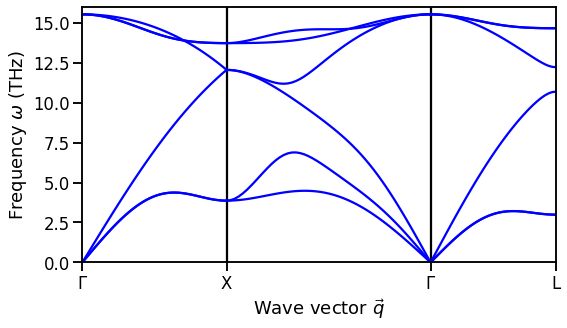

In [70]:
Nq = 51 
def get_band(q_start, q_stop, N):
    """ Return path between q_start and q_stop """
    return np.array([q_start + (q_stop-q_start)*i/(N-1) for i in range(N)])


# setup band path
G2X = get_band(np.array([0, 0, 0]), np.array([0.5, 0.5, 0]), Nq)
X2K2G = get_band(np.array([0.5, 0.5, 1.0]), np.array([0, 0, 0]), Nq)
G2L = get_band(np.array([0, 0, 0]), np.array([0.5, 0.5, 0.5]), Nq)
bands = [G2X, X2K2G, G2L]

# get phonon dispersion
phonopy.set_band_structure(bands)
qvecs, qnorms, freqs, _ = phonopy.get_band_structure()
fig = plt.figure(figsize=(8, 5))

kpts = [0.0, qnorms[0][-1], qnorms[1][-1], qnorms[2][-1]]
kpts_labels = ['$\\Gamma$', 'X', '$\\Gamma$', 'L']

plt.axvline(x=kpts[1], color='k')
plt.axvline(x=kpts[2], color='k')

for q, freq, in zip(qnorms, freqs):
    plt.plot(q, freq, color='b')

plt.xlabel('Wave vector $\\vec{q}$')
plt.ylabel('Frequency $\\omega$ (THz)')
plt.xticks(kpts, kpts_labels)
plt.xlim([0.0, qnorms[-1][-1]])
plt.ylim([0.0, 16.0])

plt.tight_layout()